## Test

The same feature definitions used during training are reconstructed for the
unseen data, and the scaler fitted during training is used to transform the
features.

Only the features selected during training are retained:

$$
\widetilde{\Theta}_{\mathrm{active}}
=
\widetilde{\Theta}
[:,\mathrm{active\_indices}]
$$

The learned coefficients are then applied to obtain the one-dimensional
representation:

$$
\boxed{
u_{\mathrm{unseen}}
=
\widetilde{\Theta}_{\mathrm{unseen,active}}c
}
$$

The resulting $u_{\mathrm{unseen}}$ is then compared with the corresponding
target $y_{\mathrm{unseen}}$ to evaluate whether the learned representation
generalises beyond the training data.

The primary information-theoretic metric is the mutual information:

$$
I(u_{\mathrm{unseen}}, y_{\mathrm{unseen}})
$$

The $u$-$y$ relationship is also visualised using a scatter plot.

A successful model should therefore satisfy both:

$$
I(u_{\mathrm{unseen}}, y_{\mathrm{unseen}})
\text{ remains high}
$$

and

$$
y_{\mathrm{unseen}} \approx f(u_{\mathrm{unseen}})
$$

with the unseen samples following a stable relationship. However, the fitting of function f is not within the scope of this notebook.

### Results

This section is used for testing model and visualise the result for current 10-parameter tests.

In [1]:
import sys
import os
import pickle
import numpy as np

sys.path.insert(0, os.path.abspath(".."))
from src.evaluation import build_theta_from_model, visualize_sparse_prediction, analyze_feature_cmi, analyze_feature_importance
from src.sparse_interp import sparse_ee_interpretation, save_sparse_result, load_sparse_result, sparse_predict
from src.function_library import build_function_library, select_top_power_features, power_features, build_power_library

In [2]:
# loading data
data = np.load(r"D:\Law\25-26\research intern\final_data.npz")
print(data.files)

X_final = data["param"]

param_names = [
    "C_p",
    "Za_p",
    "R_p",
    "Emax_rv",
    "Emin_rv",
    "C_s",
    "Za_s",
    "R_s",
    "Emax_lv",
    "Emin_lv"
]

v_lv_final = data["v_lv"]
v_rv_final = data["v_rv"]

y_v_lv_max_final = np.max(v_lv_final, axis=1)
y_v_lv_min_final = np.min(v_lv_final, axis=1)

y_v_rv_max_final = np.max(v_rv_final, axis=1)
y_v_rv_min_final = np.min(v_rv_final, axis=1)

y_v_lv_mean_final = np.mean(v_lv_final, axis=1)
y_v_rv_mean_final = np.mean(v_rv_final, axis=1)

['p_lv', 'p_rv', 'p_pa', 'v_lv', 'v_rv', 'q_av', 'q_mv', 'q_pv', 'param']


In [3]:
# load old sampling
with open("../notebook/final_data_split.pkl", "rb") as f:
    final_data_split = pickle.load(f)

final_train_idx = final_data_split["train_idx"]
final_test_idx = final_data_split["test_idx"]

X_final_train = X_final[final_train_idx]
X_final_test = X_final[final_test_idx]

y_v_lv_max_final_train = y_v_lv_max_final[final_train_idx]
y_v_lv_max_final_test = y_v_lv_max_final[final_test_idx]

y_v_lv_min_final_train = y_v_lv_min_final[final_train_idx]
y_v_lv_min_final_test = y_v_lv_min_final[final_test_idx]

y_v_rv_max_final_train = y_v_rv_max_final[final_train_idx]
y_v_rv_max_final_test = y_v_rv_max_final[final_test_idx]

y_v_rv_min_final_train = y_v_rv_min_final[final_train_idx]
y_v_rv_min_final_test = y_v_rv_min_final[final_test_idx]

y_v_lv_mean_final_train = y_v_lv_mean_final[final_train_idx]
y_v_rv_mean_final_train = y_v_rv_mean_final[final_train_idx]

y_v_lv_mean_final_test = y_v_lv_mean_final[final_test_idx]
y_v_rv_mean_final_test = y_v_rv_mean_final[final_test_idx]

In [16]:
sparse_result_v_lv_max_final = load_sparse_result("../results/sparse_result_v_lv_max_final.pkl")


sparse_result_v_lv_min_final = load_sparse_result(
    "../results/sparse_result_v_lv_min_final.pkl"
)

sparse_result_v_rv_max_final = load_sparse_result(
    "../results/sparse_result_v_rv_max_final.pkl"
)

sparse_result_v_rv_min_final = load_sparse_result(
    "../results/sparse_result_v_rv_min_final.pkl"
)

sparse_result_v_lv_mean_final = load_sparse_result(
    "../results/sparse_result_v_lv_mean_final.pkl"
)

sparse_result_v_rv_mean_final = load_sparse_result(
    "../results/sparse_result_v_rv_mean_final.pkl"
)

Loaded from ../results/sparse_result_v_lv_max_final.pkl
MI = 1.948009
Active features = 7
Loaded from ../results/sparse_result_v_lv_min_final.pkl
MI = 1.160638
Active features = 1
Loaded from ../results/sparse_result_v_rv_max_final.pkl
MI = 2.198935
Active features = 10
Loaded from ../results/sparse_result_v_rv_min_final.pkl
MI = 1.416362
Active features = 6
Loaded from ../results/sparse_result_v_lv_mean_final.pkl
MI = 2.336750
Active features = 9
Loaded from ../results/sparse_result_v_rv_mean_final.pkl
MI = 1.852360
Active features = 7


### Visualisation

MI          : 2.182244


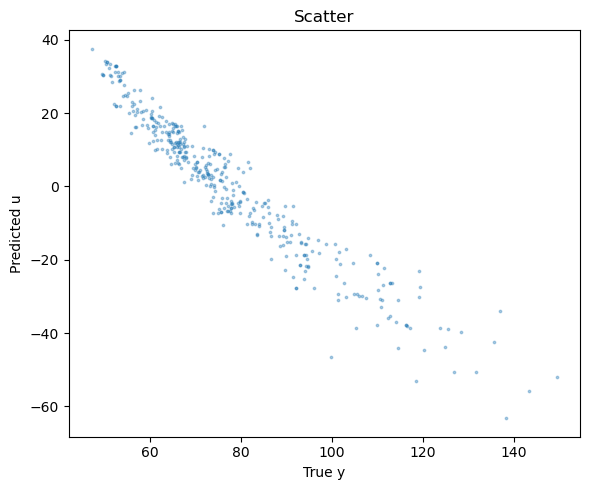

In [17]:
Theta_full_v_lv_max_final = build_theta_from_model(
    X_final_test,
    sparse_result_v_lv_max_final,
    param_names,
)

Theta_full_scaled_v_lv_max_final = (
    sparse_result_v_lv_max_final["scaler"].transform(
        Theta_full_v_lv_max_final
    )
)

Theta_scaled_v_lv_max_final = (
    Theta_full_scaled_v_lv_max_final[
        :,
        sparse_result_v_lv_max_final["active_indices"]
    ]
)

u_v_lv_max_final_test = visualize_sparse_prediction(
    Theta_scaled_v_lv_max_final,
    y_v_lv_max_final_test,
    "../results/sparse_result_v_lv_max_final.pkl",
)

MI          : 1.555601


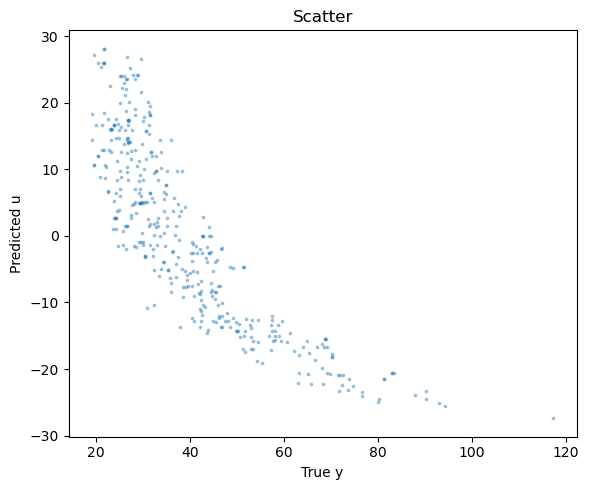

In [18]:
Theta_full_v_lv_min_final = build_theta_from_model(
    X_final_test,
    sparse_result_v_lv_min_final,
    param_names,
)

Theta_full_scaled_v_lv_min_final = (
    sparse_result_v_lv_min_final["scaler"].transform(
        Theta_full_v_lv_min_final
    )
)

Theta_scaled_v_lv_min_final = (
    Theta_full_scaled_v_lv_min_final[
        :,
        sparse_result_v_lv_min_final["active_indices"]
    ]
)

u_v_lv_min_final_test = visualize_sparse_prediction(
    Theta_scaled_v_lv_min_final,
    y_v_lv_min_final_test,
    "../results/sparse_result_v_lv_min_final.pkl",
)

MI          : 2.529527


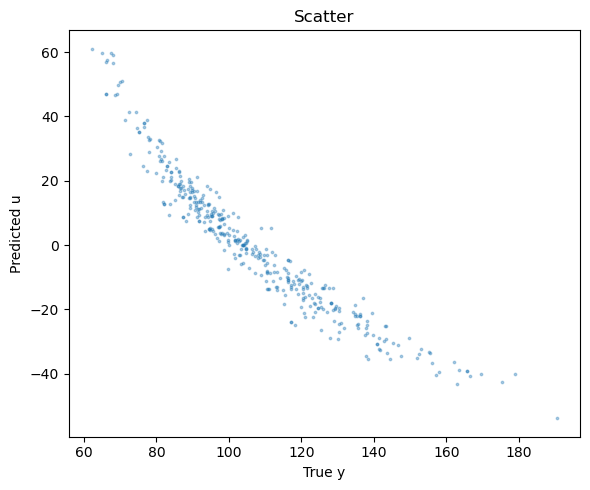

In [19]:

Theta_full_v_rv_max_final = build_theta_from_model(
    X_final_test,
    sparse_result_v_rv_max_final,
    param_names,
)

Theta_full_scaled_v_rv_max_final = (
    sparse_result_v_rv_max_final["scaler"].transform(
        Theta_full_v_rv_max_final
    )
)

Theta_scaled_v_rv_max_final = (
    Theta_full_scaled_v_rv_max_final[
        :,
        sparse_result_v_rv_max_final["active_indices"]
    ]
)

u_v_rv_max_final_test = visualize_sparse_prediction(
    Theta_scaled_v_rv_max_final,
    y_v_rv_max_final_test,
    "../results/sparse_result_v_rv_max_final.pkl",
)

MI          : 1.638298


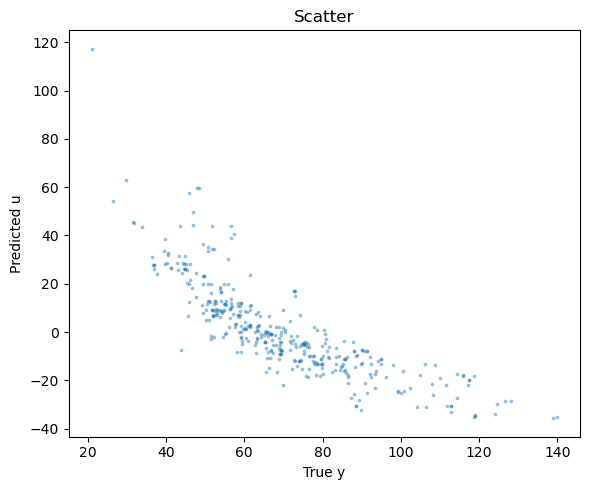

In [20]:


Theta_full_v_rv_min_final = build_theta_from_model(
    X_final_test,
    sparse_result_v_rv_min_final,
    param_names,
)

Theta_full_scaled_v_rv_min_final = (
    sparse_result_v_rv_min_final["scaler"].transform(
        Theta_full_v_rv_min_final
    )
)

Theta_scaled_v_rv_min_final = (
    Theta_full_scaled_v_rv_min_final[
        :,
        sparse_result_v_rv_min_final["active_indices"]
    ]
)

u_v_rv_min_final_test = visualize_sparse_prediction(
    Theta_scaled_v_rv_min_final,
    y_v_rv_min_final_test,
    "../results/sparse_result_v_rv_min_final.pkl",
)

MI          : 2.454968


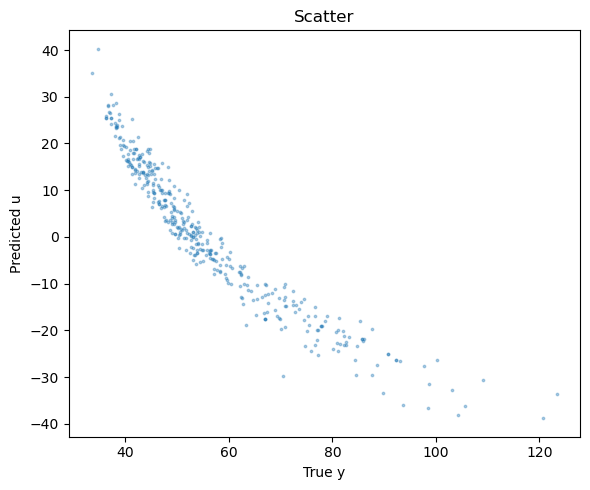

In [21]:
Theta_full_v_lv_mean_final = build_theta_from_model(
    X_final_test,
    sparse_result_v_lv_mean_final,
    param_names,
)

Theta_full_scaled_v_lv_mean_final = (
    sparse_result_v_lv_mean_final["scaler"].transform(
        Theta_full_v_lv_mean_final
    )
)

Theta_scaled_v_lv_mean_final = (
    Theta_full_scaled_v_lv_mean_final[
        :,
        sparse_result_v_lv_mean_final["active_indices"]
    ]
)

u_v_lv_mean_final_test = visualize_sparse_prediction(
    Theta_scaled_v_lv_mean_final,
    y_v_lv_mean_final_test,
    "../results/sparse_result_v_lv_mean_final.pkl",
)

MI          : 2.049600


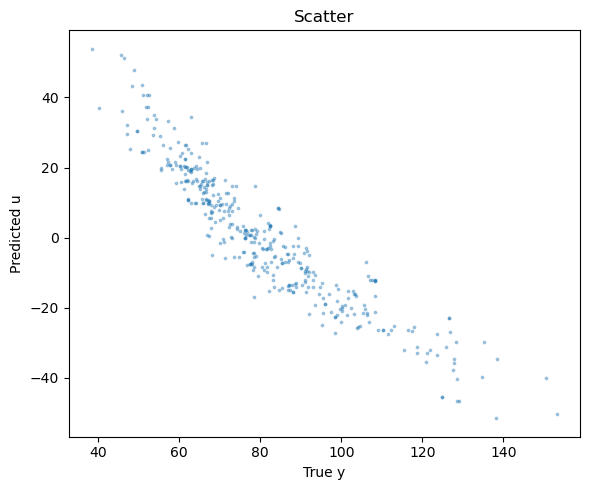

In [22]:
Theta_full_v_rv_mean_final = build_theta_from_model(
    X_final_test,
    sparse_result_v_rv_mean_final,
    param_names,
)

Theta_full_scaled_v_rv_mean_final = (
    sparse_result_v_rv_mean_final["scaler"].transform(
        Theta_full_v_rv_mean_final
    )
)

Theta_scaled_v_rv_mean_final = (
    Theta_full_scaled_v_rv_mean_final[
        :,
        sparse_result_v_rv_mean_final["active_indices"]
    ]
)

u_v_rv_mean_final_test = visualize_sparse_prediction(
    Theta_scaled_v_rv_mean_final,
    y_v_rv_mean_final_test,
    "../results/sparse_result_v_rv_mean_final.pkl",
)

### Feature Importance Evaluation

In [23]:
Theta_v_lv_max_final, feature_names_v_lv_max_final = build_function_library(
    X_final_train,
    param_names
)

Theta_scaled_v_lv_max_final = (
    sparse_result_v_lv_max_final["scaler"].transform(
        Theta_v_lv_max_final
    )
)

cmi_v_lv_max_final = analyze_feature_importance(
    sparse_result_v_lv_max_final,
    Theta_scaled_v_lv_max_final,
    y_v_lv_max_final_train
)


===== Feature Importance (Leave-One-Out MI) =====

Feature                                           Coeff         ΔMI      MI(-f)
----------------------------------------------------------------------------------
log(Emax_lv)                                    11.3302      1.3203      0.9475
C_p                                              5.4955      0.6418      1.6260
R_p                                              5.0558      0.6273      1.6405
log(C_s)                                         4.6485      0.5361      1.7317
Emax_rv                                         -4.6261      0.4757      1.7921
C_s*R_s                                          3.3608      0.3912      1.8766
Emin_rv^2                                        3.0452      0.3335      1.9343
----------------------------------------------------------------------------------
Full model MI : 2.267802


In [24]:
Theta_v_lv_min_final, feature_names_v_lv_min_final = build_function_library(
    X_final_train,
    param_names
)

Theta_scaled_v_lv_min_final = (
    sparse_result_v_lv_min_final["scaler"].transform(
        Theta_v_lv_min_final
    )
)

cmi_v_lv_min_final = analyze_feature_importance(
    sparse_result_v_lv_min_final,
    Theta_scaled_v_lv_min_final,
    y_v_lv_min_final_train
)


===== Feature Importance (Leave-One-Out MI) =====

Feature                                           Coeff         ΔMI      MI(-f)
----------------------------------------------------------------------------------
Emax_lv                                         13.6932      1.4951      0.0000
----------------------------------------------------------------------------------
Full model MI : 1.495075


In [25]:
Theta_v_rv_max_final, feature_names_v_rv_max_final = build_function_library(
    X_final_train,
    param_names
)

Theta_scaled_v_rv_max_final = (
    sparse_result_v_rv_max_final["scaler"].transform(
        Theta_v_rv_max_final
    )
)

cmi_v_rv_max_final = analyze_feature_importance(
    sparse_result_v_rv_max_final,
    Theta_scaled_v_rv_max_final,
    y_v_rv_max_final_train
)


===== Feature Importance (Leave-One-Out MI) =====

Feature                                           Coeff         ΔMI      MI(-f)
----------------------------------------------------------------------------------
C_s*R_s                                         10.7838      1.3404      1.2927
Emax_rv*R_s                                      7.4735      0.9055      1.7277
Za_s                                             7.0829      0.8704      1.7627
log(Emax_rv)                                     6.5151      0.8445      1.7886
Emin_rv                                          6.1177      0.7723      1.8609
log(C_p)                                         5.7489      0.7593      1.8739
R_p*Za_s                                        -5.4566      0.6734      1.9598
C_p*Emax_rv                                      6.0544      0.6481      1.9850
C_p*R_p                                          4.6159      0.5229      2.1102
log(Emax_lv)                                    -4.8114      0.49

In [26]:
Theta_v_rv_min_final, feature_names_v_rv_min_final = build_function_library(
    X_final_train,
    param_names
)

Theta_scaled_v_rv_min_final = (
    sparse_result_v_rv_min_final["scaler"].transform(
        Theta_v_rv_min_final
    )
)

cmi_v_rv_min_final = analyze_feature_importance(
    sparse_result_v_rv_min_final,
    Theta_scaled_v_rv_min_final,
    y_v_rv_min_final_train
)


===== Feature Importance (Leave-One-Out MI) =====

Feature                                           Coeff         ΔMI      MI(-f)
----------------------------------------------------------------------------------
Emax_rv                                         11.8113      0.6267      0.9351
Za_s                                            -5.2014      0.3815      1.1803
Za_s*R_s                                         5.3025      0.3453      1.2164
C_p                                              3.1858      0.3318      1.2300
C_p*C_s                                          3.1850      0.3269      1.2349
Emax_rv^2                                        5.7888      0.1724      1.3894
----------------------------------------------------------------------------------
Full model MI : 1.561772


In [27]:
Theta_v_lv_mean_final, feature_names_v_lv_mean_final = build_function_library(
    X_final_train,
    param_names
)

Theta_scaled_v_lv_mean_final = (
    sparse_result_v_lv_mean_final["scaler"].transform(
        Theta_v_lv_mean_final
    )
)

cmi_v_lv_mean_final = analyze_feature_importance(
    sparse_result_v_lv_mean_final,
    Theta_scaled_v_lv_mean_final,
    y_v_lv_mean_final_train
)


===== Feature Importance (Leave-One-Out MI) =====

Feature                                           Coeff         ΔMI      MI(-f)
----------------------------------------------------------------------------------
C_s*R_s                                          4.4974      0.9106      1.6538
R_p*Emax_lv                                      5.8530      0.8320      1.7324
log(Emax_lv)                                     6.8031      0.6911      1.8732
C_p*Emax_rv                                      3.2082      0.6601      1.9042
Emax_rv                                         -3.3998      0.5820      1.9824
Emax_lv*Emin_lv                                  3.3667      0.5228      2.0416
R_s*Emax_lv                                     -3.0585      0.4030      2.1614
Za_s*R_s                                        -2.0107      0.3480      2.2164
Emin_rv*Za_s                                     2.4153      0.2461      2.3183
-----------------------------------------------------------------

In [28]:
Theta_v_rv_mean_final, feature_names_v_rv_mean_final = build_function_library(
    X_final_train,
    param_names
)

Theta_scaled_v_rv_mean_final = (
    sparse_result_v_rv_mean_final["scaler"].transform(
        Theta_v_rv_mean_final
    )
)

cmi_v_rv_mean_final = analyze_feature_importance(
    sparse_result_v_rv_mean_final,
    Theta_scaled_v_rv_mean_final,
    y_v_rv_mean_final_train
)


===== Feature Importance (Leave-One-Out MI) =====

Feature                                           Coeff         ΔMI      MI(-f)
----------------------------------------------------------------------------------
log(Emax_rv)                                    11.2103      0.9368      1.1646
Emax_rv*R_s                                     10.5485      0.9141      1.1874
log(C_p)                                         6.0564      0.5877      1.5138
Emin_rv                                          4.5292      0.4645      1.6369
R_p^2                                           -4.7452      0.4457      1.6557
log(C_s)                                         6.5301      0.3939      1.7075
C_p^2                                            3.7056      0.3476      1.7538
----------------------------------------------------------------------------------
Full model MI : 2.101462
